<a href="https://colab.research.google.com/github/khushi-2003/AI-projects/blob/main/PowerEnergyPrediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Power Energy prediction project

Step 1 - Data import

In [2]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/khushi-2003/Datasets/refs/heads/main/PowerPlant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.shape

(9568, 5)

In [5]:
df.duplicated().sum()

np.int64(41)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

Step 2 - Seperate x and y features.

  y : PE


In [8]:
x = df.drop(columns='PE')
y = df[['PE']]

In [9]:
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


Step 3 - Feature Engineering


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(
    SimpleImputer(strategy = 'mean'),
    StandardScaler()
).set_output(transform='pandas')

In [12]:
x_pre = num_pipe.fit_transform(x)
x_pre.head()

,AT,V,AP,RH
0,-1.520448,-1.066041,-0.403535,1.141599
1,0.534897,0.330813,-0.309262,0.059223
2,1.354348,0.205475,-1.024725,-2.151400
3,-0.079020,-0.362884,-1.012941,0.236538
4,-1.055645,-1.074713,0.655349,1.633837


Step 4 - Split training and testing data


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pre,y,train_size=0.75,random_state=21)

Step 5 - Model Building

In [14]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import EarlyStopping

#initialise the model
model = Sequential()

#input layer
model.add(Input(shape=(x_train.shape[1],)))

#add the hidden layer 1
model.add(Dense(units=32,activation='relu'))


# Hidden layer2
model.add(Dense(units=16,activation='relu'))



#Output layer
model.add(Dense(units=1,activation='linear'))

In [15]:
model.compile(optimizer='adam',loss='mae',metrics =['accuracy'])

In [16]:
nn=model.fit(x_train,y_train,validation_split=0.2,epochs=200)

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0000e+00 - loss: 449.2497 - val_accuracy: 0.0000e+00 - val_loss: 438.2589
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 392.8184 - val_accuracy: 0.0000e+00 - val_loss: 319.7839
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 199.0141 - val_accuracy: 0.0000e+00 - val_loss: 115.1308
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 101.5502 - val_accuracy: 0.0000e+00 - val_loss: 83.8610
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 70.9380 - val_accuracy: 0.0000e+00 - val_loss: 53.2751
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 40.5140 - val_accuracy: 0.0000e+00 - val_loss: 27.4724
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 20.3349 - val_accuracy: 0.0000e+00 - val_loss: 14.4105
Epoch 8/200
179/179

Step 6 - Learning curve

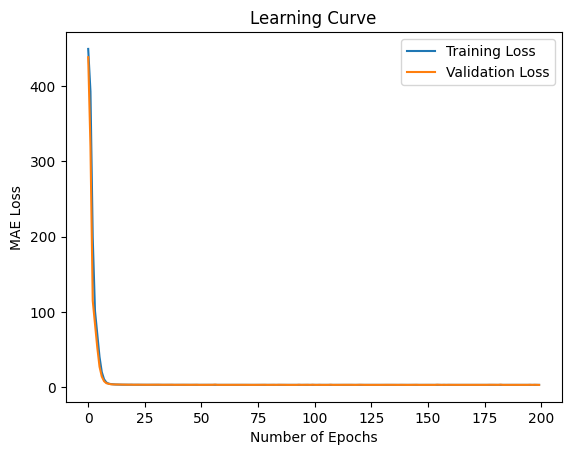

In [17]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MAE Loss")
plt.legend()
plt.show()

Step 7 - Model Evaluation

In [18]:
yprobs = model.predict(x_test)
yprobs[:5]


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[448.24265],
       [448.6027 ],
       [461.08395],
       [465.31467],
       [462.89136]], dtype=float32)

In [19]:
from sklearn.metrics import r2_score
print(r2_score(yprobs,y_test))

0.9389979839324951


Dropout

In [21]:
# Intialize the model
model_do = Sequential()

# Add the Input layer
model_do.add(Input(shape=(x_train.shape[1],)))

# Add the Hidden layer 1
model_do.add(Dense(units=32,activation='relu'))

# Add the Dropout layer
model_do.add(Dropout(rate=0.3))

# Add the Hidden layer2
model_do.add(Dense(units=16,activation='relu'))

# Add the Dropout layer
model_do.add(Dropout(rate=0.15))

# Add the Output layer
model_do.add(Dense(units=1,activation='linear'))


In [22]:
model_do.compile(optimizer='adam',loss='mae',metrics =['accuracy'])

In [23]:
es = EarlyStopping(monitor='val_loss',patience=10)


In [24]:
nn_do = model_do.fit(x_train,y_train,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0000e+00 - loss: 447.9087 - val_accuracy: 0.0000e+00 - val_loss: 432.3938
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 371.7694 - val_accuracy: 0.0000e+00 - val_loss: 270.0551
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 176.1781 - val_accuracy: 0.0000e+00 - val_loss: 113.4971
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 124.2044 - val_accuracy: 0.0000e+00 - val_loss: 83.1892
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 100.7329 - val_accuracy: 0.0000e+00 - val_loss: 56.4020
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 84.1404 - val_accuracy: 0.0000e+00 - val_loss: 36.3479
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 74.9962 - val_accuracy: 0.0000e+00 - val_loss: 29.7806
Epoch 8/200
179/17

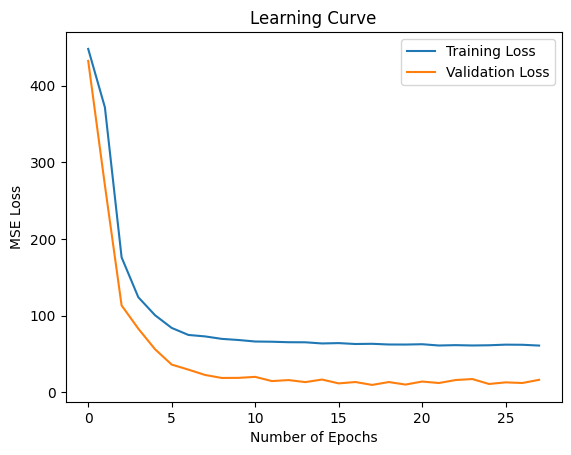

In [25]:
import matplotlib.pyplot as plt
plt.plot(nn_do.history['loss'],label='Training Loss')
plt.plot(nn_do.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [26]:
yprobs_do = model_do.predict(x_test)
yprobs_do[:5]


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[434.11813],
       [432.73312],
       [447.0032 ],
       [444.69217],
       [444.39713]], dtype=float32)

In [27]:
from sklearn.metrics import r2_score
print(r2_score(yprobs_do,y_test))

-0.20691096782684326


Batch Normalisation

In [28]:
from keras.layers import BatchNormalization
# Intialize the model
model_bn = Sequential()

# Add the Input layer
model_bn.add(Input(shape=(x_train.shape[1],)))

# Add the Hidden layer 1
model_bn.add(Dense(units=32,activation='relu'))

# Add the BatchNormalization
model_bn.add(BatchNormalization())

# Add the Hidden layer2
model_bn.add(Dense(units=16,activation='relu'))

# Add the BatchNormalization
model_bn.add(BatchNormalization())

# Add the Output layer
model_bn.add(Dense(units=1,activation='linear'))

In [29]:
model_bn.compile(optimizer='adam',loss='mae',metrics =['accuracy'])

In [30]:
es = EarlyStopping(monitor='val_loss',patience=10)


In [31]:
nn_bn = model_bn.fit(x_train,y_train,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0000e+00 - loss: 453.4465 - val_accuracy: 0.0000e+00 - val_loss: 453.0094
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 450.3167 - val_accuracy: 0.0000e+00 - val_loss: 448.6187
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 444.5976 - val_accuracy: 0.0000e+00 - val_loss: 441.6792
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 436.3584 - val_accuracy: 0.0000e+00 - val_loss: 432.1169
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 425.7314 - val_accuracy: 0.0000e+00 - val_loss: 420.9795
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 412.8527 - val_accuracy: 0.0000e+00 - val_loss: 406.6320
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 397.8493 - val_accuracy: 0.0000e+00 - val_loss: 390.8768
Epoch 8/200


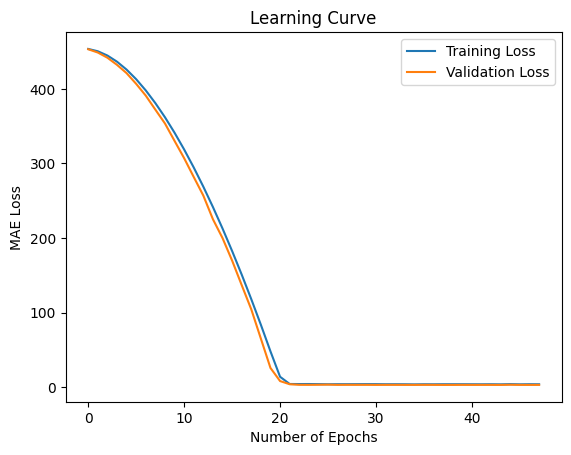

In [32]:
import matplotlib.pyplot as plt
plt.plot(nn_bn.history['loss'],label='Training Loss')
plt.plot(nn_bn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MAE Loss")
plt.legend()
plt.show()

In [33]:
yprobs_bn = model.predict(x_test)
yprobs_bn[:5]


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[448.24265],
       [448.6027 ],
       [461.08395],
       [465.31467],
       [462.89136]], dtype=float32)

In [34]:
from sklearn.metrics import r2_score
print(r2_score(yprobs_bn,y_test))

0.9389979839324951


Hence, we can use model or model_bn as they provide R2 score > 93% for future predictions.

